# **Objective 1: IND v. PHL Rainfall**
*Notebook created Jan. 21, 2026*

This notebook documents the data analyses performed to address the following objective:

<p style="color:royalblue; text-align:center"><em>Evaluate the relationship between Philippine southwest monsoon rainfall as represented by the LSWMI and AIRI.</em></p>

<div style="background-color:lightsalmon; border-left:6px solid salmon; padding:15px;">
    <strong>Note:</strong> Improve the wording of this objective. This no longer reflects the methods and analyses performed for this objective.
</div>

The meteorological subdivisions of India are grouped into the following regions:

[insert India and their subdivisions here]

| Region | Subdivisions |
| :---: | :--- |
| Central India | Odisha, West Madhya Pradesh, East Madhya Pradesh, Gujarat Region, Saurashtra and Kutch, Konkan and Goa, Madhya Maharashtra, Marathwada, Vidarbha, Chhattisgarh |
| Northeastern India | Arunachal Pradesh, Assam and Meghalaya, Nagaland–Manipur–Mizoram–Tripura, Sub-Himalayan West Bengal and Sikkim, Gangetic West Bengal, Jharkhand, Bihar |
| Northwestern India | East Uttar Pradesh, West Uttar Pradesh, Uttarakhand, Haryana–Chandigarh–Delhi, Punjab, Himachal Pradesh, Jammu and Kashmir and Ladakh, West Rajasthan, East Rajasthan |
| Peninsular India | Andaman and Nicobar Islands, Coastal Andhra Pradesh and Yanam, Telangana, Rayalaseema, Tamil Nadu–Puducherry–Karaikal, Coastal Karnataka, North Interior Karnataka, South Interior Karnataka, Kerala and Mahe, Lakshadweep |

#### **Table of Contents**
1. [Datasets](#1.-Datasets)
2. [Time Series](#2.-Time-Series)
3. [Interannual Relationship Between ISM and SWM](#3.-Interannual-Relationship-Between-ISM-and-SWM)
4. [Discussion](#4.-Discussion)

## **1. Datasets**

The following datasets have been downloaded and prepared.

| Dataset | Parameter | Temporal Resolution | Period | Source | Remarks |
| :--- | :---: | :---: | :---: | :--- | :--- |
| All-India Rainfall Series | Rainfall (India) | Monthly | 1901 – present | [India Meteorological Department](https://dsp.imdpune.gov.in/home_ogd_rainfall.php) | No preparation, used as is |
| PHL station rainfall | Rainfall (Philippines) | Daily | 1979 – 2024* | [DOST-PAGASA](https://www.pagasa.dost.gov.ph/) | Weighted by inverse distance weighing and averaged to monthly |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, t

PHL_FILE = r"C:\Users\Nitro 5\Documents\MS\Thesis\GitHub\MS_Thesis_SWM\01_data\01_raw\02_PHL\mean_monthly_rainfall.csv"
IND_FILES = {
    "Whole_IND": r"C:\Users\Nitro 5\Documents\MS\Thesis\GitHub\MS_Thesis_SWM\01_data\01_raw\01_IND\AIR_Whole-IND.csv",
    "Central_IND": r"C:\Users\Nitro 5\Documents\MS\Thesis\GitHub\MS_Thesis_SWM\01_data\01_raw\01_IND\AIR_Cen-IND.csv",
    "NE_IND": r"C:\Users\Nitro 5\Documents\MS\Thesis\GitHub\MS_Thesis_SWM\01_data\01_raw\01_IND\AIR_NE-IND.csv",
    "NW_IND": r"C:\Users\Nitro 5\Documents\MS\Thesis\GitHub\MS_Thesis_SWM\01_data\01_raw\01_IND\AIR_NW-IND.csv",
    "Peninsula_IND": r"C:\Users\Nitro 5\Documents\MS\Thesis\GitHub\MS_Thesis_SWM\01_data\01_raw\01_IND\AIR_Pen-IND.csv",
}

phl = pd.read_csv(PHL_FILE)
phl.rename(columns={"year": "Year"}, inplace=True)
ind = {k: pd.read_csv(v) for k, v in IND_FILES.items()}

# Clip data to 1979-2020
phl = phl[(phl["Year"] >= 1979) & (phl["Year"] <= 2020)]
for k in ind:
    ind[k] = ind[k][(ind[k]["Year"] >= 1979) & (ind[k]["Year"] <= 2020)]

## **2. Time Series**

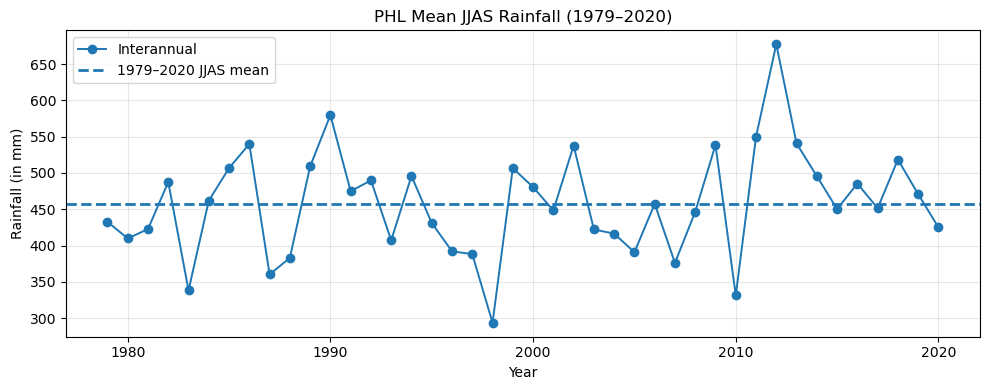

In [2]:
phl_seasonal_mean = phl["annual"].mean()

plt.figure(figsize=(10, 4))
plt.plot(phl["Year"], phl["annual"], marker="o", linewidth=1.4, label="Interannual")
plt.axhline(phl_seasonal_mean, linestyle="--", linewidth=2,
            label=f"1979–2020 JJAS mean")

plt.title("PHL Mean JJAS Rainfall (1979–2020)")
plt.xlabel("Year")
plt.ylabel("Rainfall (in mm)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<p style="text-align:center"><strong>Fig. 1.</strong> Interannual time series of Philippine (PHL) mean JJAS rainfall from 1979 to 2020.</p>

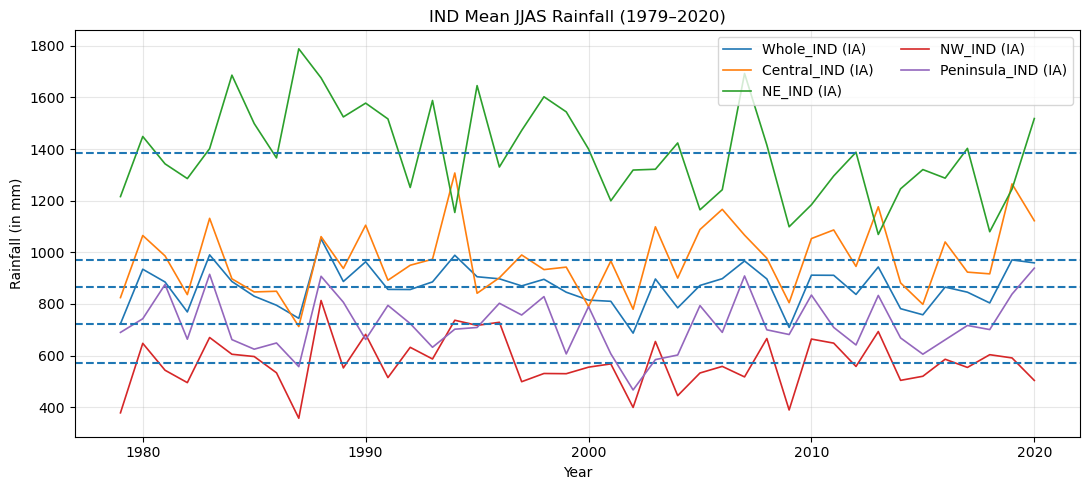

In [3]:
plt.figure(figsize=(11, 5))

for name, df in ind.items():
    mean_val = df["Monsoon Season"].mean()
    plt.plot(df["Year"], df["Monsoon Season"], linewidth=1.2, label=f"{name} (IA)")
    plt.axhline(mean_val, linestyle="--", linewidth=1.5)

plt.title("IND Mean JJAS Rainfall (1979–2020)")
plt.xlabel("Year")
plt.ylabel("Rainfall (in mm)")
plt.legend(ncol=2)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<p style="text-align:center"><strong>Fig. 2.</strong> Interannual time series of Indian (IND) mean JJAS rainfall from 1979 to 2020 for all-India, central India, northeastern India, northwestern India, and peninsular India.</p>

## **3. Interannual Relationship Between ISM and SWM**
The long-term JJAS mean time series for Philippine rainfall data will be derived from monthly averages of PAGASA station rainfall. Pearson correlation will be performed to  quantify the interannual relationship between the Indian summer monsoon (ISM) and the Philippine southwest monsoon (SWM), as divided into the following pairs:
- PHL vs whole IND
- PHL vs central IND
- PHL vs NE IND
- PHL vs NW IND
- PHL vs peninsular IND

### **2a. Pearson Correlation**

#### **PHL vs Whole IND**

PHL vs Whole India (1979–2020) | r = -0.263, p = 0.0921


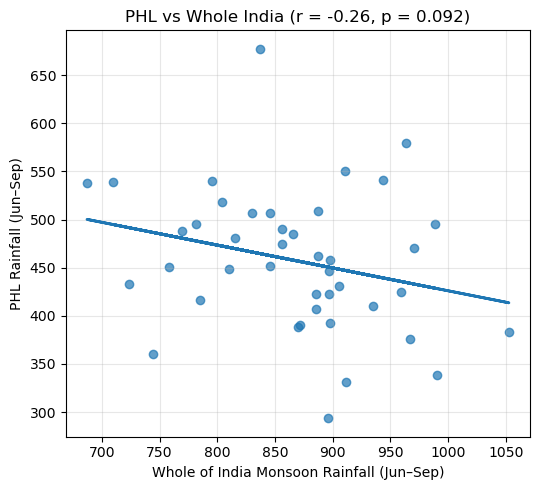

In [4]:
# Pearson
df = pd.merge(
    phl[["Year", "annual"]],
    ind["Whole_IND"][["Year", "Monsoon Season"]],
    on="Year",
    how="inner"
)

r, p = pearsonr(df["annual"], df["Monsoon Season"])
print(f"PHL vs Whole India (1979–2020) | r = {r:.3f}, p = {p:.4f}")

# Plot
x = df["Monsoon Season"]
y = df["annual"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(5.5, 5))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, m*x + b, linewidth=2)

plt.xlabel("Whole of India Monsoon Rainfall (Jun–Sep)")
plt.ylabel("PHL Rainfall (Jun–Sep)")
plt.title(f"PHL vs Whole India (r = {r:.2f}, p = {p:.3f})")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **PHL vs Central IND**

PHL vs Central India (1979–2020) | r = -0.070, p = 0.6587


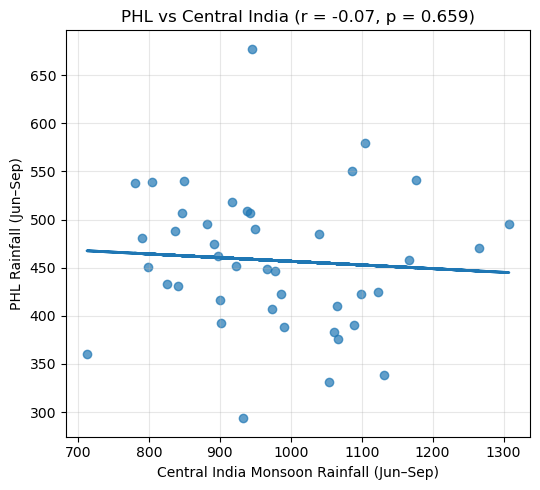

In [5]:
# Pearson
df = pd.merge(
    phl[["Year", "annual"]],
    ind["Central_IND"][["Year", "Monsoon Season"]],
    on="Year",
    how="inner"
)

r, p = pearsonr(df["annual"], df["Monsoon Season"])
print(f"PHL vs Central India (1979–2020) | r = {r:.3f}, p = {p:.4f}")

# Plot
x = df["Monsoon Season"]
y = df["annual"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(5.5, 5))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, m*x + b, linewidth=2)

plt.xlabel("Central India Monsoon Rainfall (Jun–Sep)")
plt.ylabel("PHL Rainfall (Jun–Sep)")
plt.title(f"PHL vs Central India (r = {r:.2f}, p = {p:.3f})")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **PHL vs NE IND**

PHL vs NE India (1979–2020) | r = -0.300, p = 0.0532


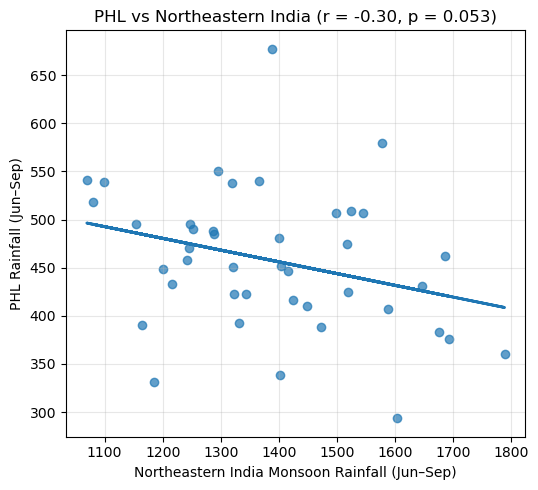

In [6]:
# Pearson
df = pd.merge(
    phl[["Year", "annual"]],
    ind["NE_IND"][["Year", "Monsoon Season"]],
    on="Year",
    how="inner"
)

r, p = pearsonr(df["annual"], df["Monsoon Season"])
print(f"PHL vs NE India (1979–2020) | r = {r:.3f}, p = {p:.4f}")

# Plot
x = df["Monsoon Season"]
y = df["annual"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(5.5, 5))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, m*x + b, linewidth=2)

plt.xlabel("Northeastern India Monsoon Rainfall (Jun–Sep)")
plt.ylabel("PHL Rainfall (Jun–Sep)")
plt.title(f"PHL vs Northeastern India (r = {r:.2f}, p = {p:.3f})")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **PHL vs NW IND**

PHL vs NW India (1979–2020) | r = -0.039, p = 0.8071


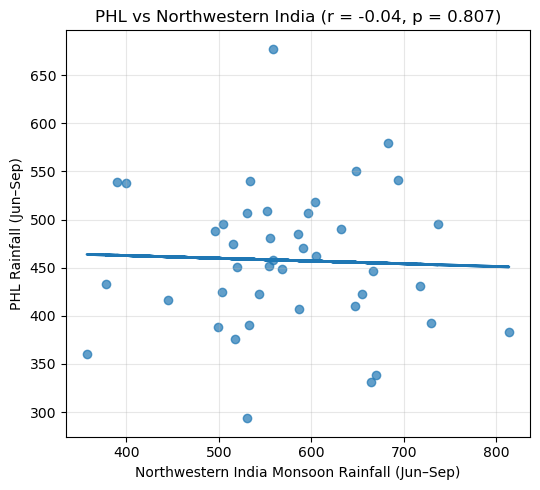

In [7]:
# Pearson
df = pd.merge(
    phl[["Year", "annual"]],
    ind["NW_IND"][["Year", "Monsoon Season"]],
    on="Year",
    how="inner"
)

r, p = pearsonr(df["annual"], df["Monsoon Season"])
print(f"PHL vs NW India (1979–2020) | r = {r:.3f}, p = {p:.4f}")

# Plot
x = df["Monsoon Season"]
y = df["annual"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(5.5, 5))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, m*x + b, linewidth=2)

plt.xlabel("Northwestern India Monsoon Rainfall (Jun–Sep)")
plt.ylabel("PHL Rainfall (Jun–Sep)")
plt.title(f"PHL vs Northwestern India (r = {r:.2f}, p = {p:.3f})")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **PHL vs Peninsular IND**

PHL vs Peninsular India (1979–2020) | r = -0.409, p = 0.0072


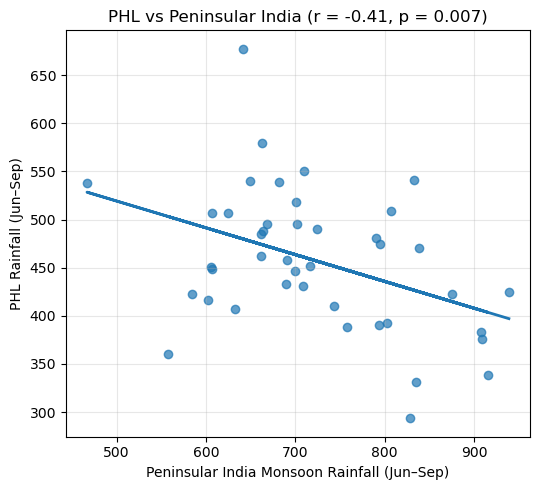

In [8]:
# Pearson
df = pd.merge(
    phl[["Year", "annual"]],
    ind["Peninsula_IND"][["Year", "Monsoon Season"]],
    on="Year",
    how="inner"
)

r, p = pearsonr(df["annual"], df["Monsoon Season"])
print(f"PHL vs Peninsular India (1979–2020) | r = {r:.3f}, p = {p:.4f}")

# Plot
x = df["Monsoon Season"]
y = df["annual"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(5.5, 5))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, m*x + b, linewidth=2)

plt.xlabel("Peninsular India Monsoon Rainfall (Jun–Sep)")
plt.ylabel("PHL Rainfall (Jun–Sep)")
plt.title(f"PHL vs Peninsular India (r = {r:.2f}, p = {p:.3f})")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **Significance (Student's *t*-test)**

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, t

ALPHA = 0.05  # 95% confidence level

correlation_targets = {
    "Whole_IND": "PHL vs Whole India",
    "Central_IND": "PHL vs Central India",
    "NE_IND": "PHL vs NE India",
    "NW_IND": "PHL vs NW India",
    "Peninsula_IND": "PHL vs Peninsular India",
}

In [10]:
results = {}

for key, label in correlation_targets.items():

    df_corr = pd.merge(
        phl[["Year", "annual"]],
        ind[key][["Year", "Monsoon Season"]],
        on="Year",
        how="inner"
    ).dropna()

    x = df_corr["Monsoon Season"]
    y = df_corr["annual"]

    # Pearson correlation
    r, p = pearsonr(x, y)

    # Student's t-test
    n = len(df_corr)
    dfree = n - 2
    t_stat = r * np.sqrt(dfree / (1 - r**2))
    p_t = 2 * (1 - t.cdf(abs(t_stat), df=dfree))
    t_crit = t.ppf(1 - ALPHA/2, df=dfree)

    results[key] = {
        "label": label,
        "n": n,
        "r": r,
        "p": p,
        "t_stat": t_stat,
        "t_crit": t_crit,
        "significant_95": abs(t_stat) > t_crit,
        "df": df_corr
    }

In [11]:
for key, res in results.items():
    print(f"\n{res['label']}")
    print("-" * len(res["label"]))
    print(f"Sample size (n): {res['n']}")
    print(f"Pearson r: {res['r']:.3f}")
    print(f"t-statistic: {res['t_stat']:.3f}")
    print(f"Critical t (95% CL): ±{res['t_crit']:.3f}")
    print(f"p-value: {res['p']:.4f}")

    if res["significant_95"]:
        print("Result: Significant at the 95% confidence level")
    else:
        print("Result: Not significant at the 95% confidence level")


PHL vs Whole India
------------------
Sample size (n): 42
Pearson r: -0.263
t-statistic: -1.726
Critical t (95% CL): ±2.021
p-value: 0.0921
Result: Not significant at the 95% confidence level

PHL vs Central India
--------------------
Sample size (n): 42
Pearson r: -0.070
t-statistic: -0.445
Critical t (95% CL): ±2.021
p-value: 0.6587
Result: Not significant at the 95% confidence level

PHL vs NE India
---------------
Sample size (n): 42
Pearson r: -0.300
t-statistic: -1.992
Critical t (95% CL): ±2.021
p-value: 0.0532
Result: Not significant at the 95% confidence level

PHL vs NW India
---------------
Sample size (n): 42
Pearson r: -0.039
t-statistic: -0.246
Critical t (95% CL): ±2.021
p-value: 0.8071
Result: Not significant at the 95% confidence level

PHL vs Peninsular India
-----------------------
Sample size (n): 42
Pearson r: -0.409
t-statistic: -2.832
Critical t (95% CL): ±2.021
p-value: 0.0072
Result: Significant at the 95% confidence level


### **2b. Linear Regression**

#### **PHL vs Whole IND**

In [12]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.merge(
    phl[["Year", "annual"]],
    ind["Whole_IND"][["Year", "Monsoon Season"]],
    on="Year",
    how="inner"
)

x = df["Monsoon Season"]
y = df["annual"]

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

beta0 = model.params["const"]
beta1 = model.params["Monsoon Season"]
p_beta1 = model.pvalues["Monsoon Season"]
r2 = model.rsquared

print("PHL vs Whole India (1979–2020)")
print(f"Slope (β₁) = {beta1:.3f}, p = {p_beta1:.4f}")
print(f"Intercept (β₀) = {beta0:.3f}")
print(f"R² = {r2:.3f}")

PHL vs Whole India (1979–2020)
Slope (β₁) = -0.237, p = 0.0921
Intercept (β₀) = 663.048
R² = 0.069


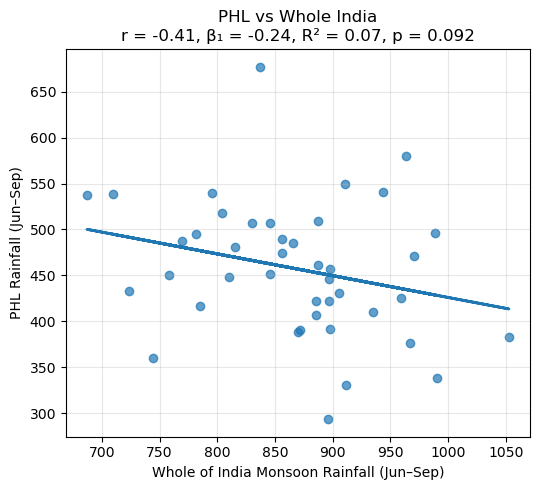

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5.5, 5))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, beta0 + beta1 * x, linewidth=2)

plt.xlabel("Whole of India Monsoon Rainfall (Jun–Sep)")
plt.ylabel("PHL Rainfall (Jun–Sep)")
plt.title(
    f"PHL vs Whole India\n"
    f"r = {r:.2f}, β₁ = {beta1:.2f}, R² = {r2:.2f}, p = {p_beta1:.3f}"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **PHL vs Central IND**

In [14]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.merge(
    phl[["Year", "annual"]],
    ind["Central_IND"][["Year", "Monsoon Season"]],
    on="Year",
    how="inner"
)

x = df["Monsoon Season"]
y = df["annual"]

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

beta0 = model.params["const"]
beta1 = model.params["Monsoon Season"]
p_beta1 = model.pvalues["Monsoon Season"]
r2 = model.rsquared

print("PHL vs Central India (1979–2020)")
print(f"Slope (β₁) = {beta1:.3f}, p = {p_beta1:.4f}")
print(f"Intercept (β₀) = {beta0:.3f}")
print(f"R² = {r2:.3f}")

PHL vs Central India (1979–2020)
Slope (β₁) = -0.038, p = 0.6587
Intercept (β₀) = 494.671
R² = 0.005


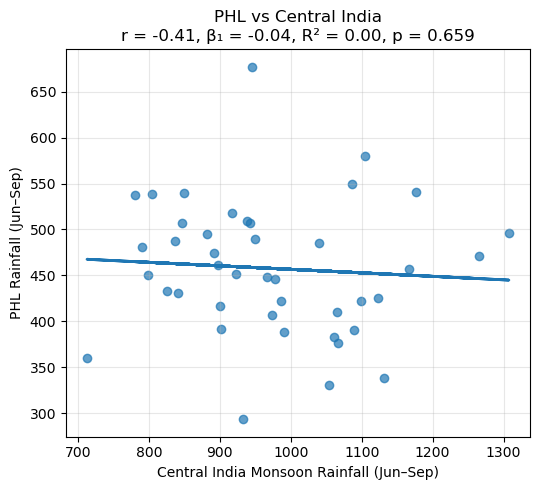

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5.5, 5))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, beta0 + beta1 * x, linewidth=2)

plt.xlabel("Central India Monsoon Rainfall (Jun–Sep)")
plt.ylabel("PHL Rainfall (Jun–Sep)")
plt.title(
    f"PHL vs Central India\n"
    f"r = {r:.2f}, β₁ = {beta1:.2f}, R² = {r2:.2f}, p = {p_beta1:.3f}"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **PHL vs NE IND**

In [16]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.merge(
    phl[["Year", "annual"]],
    ind["NE_IND"][["Year", "Monsoon Season"]],
    on="Year",
    how="inner"
)

x = df["Monsoon Season"]
y = df["annual"]

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

beta0 = model.params["const"]
beta1 = model.params["Monsoon Season"]
p_beta1 = model.pvalues["Monsoon Season"]
r2 = model.rsquared

print("PHL vs NE India (1979–2020)")
print(f"Slope (β₁) = {beta1:.3f}, p = {p_beta1:.4f}")
print(f"Intercept (β₀) = {beta0:.3f}")
print(f"R² = {r2:.3f}")

PHL vs NE India (1979–2020)
Slope (β₁) = -0.122, p = 0.0532
Intercept (β₀) = 626.755
R² = 0.090


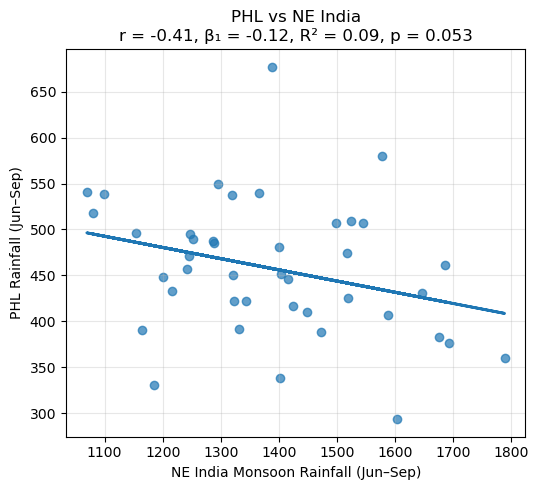

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5.5, 5))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, beta0 + beta1 * x, linewidth=2)

plt.xlabel("NE India Monsoon Rainfall (Jun–Sep)")
plt.ylabel("PHL Rainfall (Jun–Sep)")
plt.title(
    f"PHL vs NE India\n"
    f"r = {r:.2f}, β₁ = {beta1:.2f}, R² = {r2:.2f}, p = {p_beta1:.3f}"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **PHL vs NW IND**

In [18]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.merge(
    phl[["Year", "annual"]],
    ind["NW_IND"][["Year", "Monsoon Season"]],
    on="Year",
    how="inner"
)

x = df["Monsoon Season"]
y = df["annual"]

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

beta0 = model.params["const"]
beta1 = model.params["Monsoon Season"]
p_beta1 = model.pvalues["Monsoon Season"]
r2 = model.rsquared

print("PHL vs NW India (1979–2020)")
print(f"Slope (β₁) = {beta1:.3f}, p = {p_beta1:.4f}")
print(f"Intercept (β₀) = {beta0:.3f}")
print(f"R² = {r2:.3f}")

PHL vs NW India (1979–2020)
Slope (β₁) = -0.028, p = 0.8071
Intercept (β₀) = 473.920
R² = 0.002


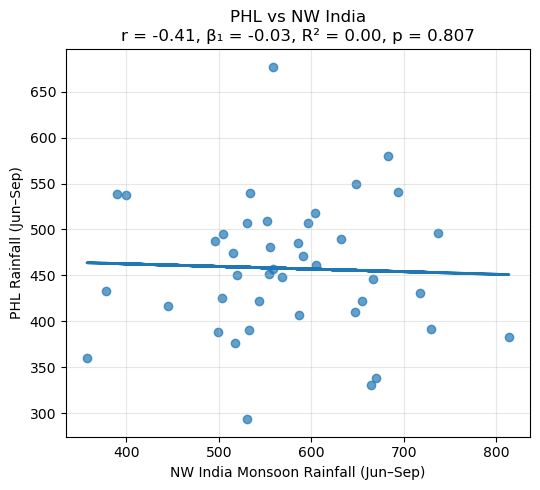

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5.5, 5))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, beta0 + beta1 * x, linewidth=2)

plt.xlabel("NW India Monsoon Rainfall (Jun–Sep)")
plt.ylabel("PHL Rainfall (Jun–Sep)")
plt.title(
    f"PHL vs NW India\n"
    f"r = {r:.2f}, β₁ = {beta1:.2f}, R² = {r2:.2f}, p = {p_beta1:.3f}"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **PHL vs Peninsular IND**

In [20]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

df = pd.merge(
    phl[["Year", "annual"]],
    ind["Peninsula_IND"][["Year", "Monsoon Season"]],
    on="Year",
    how="inner"
)

x = df["Monsoon Season"]
y = df["annual"]

X = sm.add_constant(x)
model = sm.OLS(y, X).fit()

beta0 = model.params["const"]
beta1 = model.params["Monsoon Season"]
p_beta1 = model.pvalues["Monsoon Season"]
r2 = model.rsquared

print("PHL vs Peninsular India (1979–2020)")
print(f"Slope (β₁) = {beta1:.3f}, p = {p_beta1:.4f}")
print(f"Intercept (β₀) = {beta0:.3f}")
print(f"R² = {r2:.3f}")

PHL vs Peninsular India (1979–2020)
Slope (β₁) = -0.278, p = 0.0072
Intercept (β₀) = 658.419
R² = 0.167


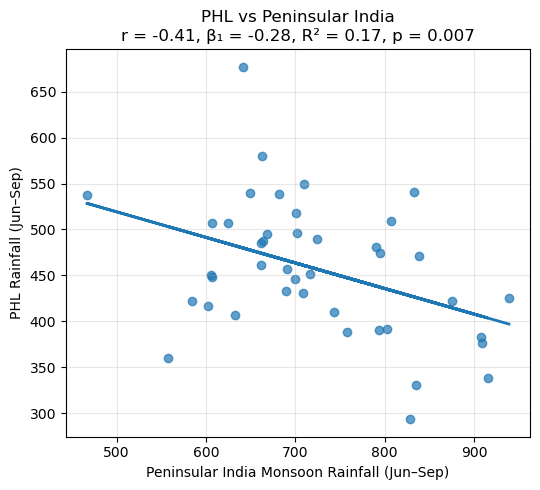

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5.5, 5))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, beta0 + beta1 * x, linewidth=2)

plt.xlabel("Peninsular India Monsoon Rainfall (Jun–Sep)")
plt.ylabel("PHL Rainfall (Jun–Sep)")
plt.title(
    f"PHL vs Peninsular India\n"
    f"r = {r:.2f}, β₁ = {beta1:.2f}, R² = {r2:.2f}, p = {p_beta1:.3f}"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### **Significance**

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t, f

ALPHA = 0.05  # 95% confidence level

regression_targets = {
    "Whole_IND": "PHL vs Whole India",
    "Central_IND": "PHL vs Central India",
    "NE_IND": "PHL vs NE India",
    "NW_IND": "PHL vs NW India",
    "Peninsula_IND": "PHL vs Peninsular India",
}

reg_results = {}

for key, label in regression_targets.items():

    df_reg = pd.merge(
        phl[["Year", "annual"]],
        ind[key][["Year", "Monsoon Season"]],
        on="Year",
        how="inner"
    ).dropna()

    x = df_reg["Monsoon Season"].values
    y = df_reg["annual"].values

    n = len(df_reg)
    dfree = n - 2

    # Linear regression (OLS via closed-form solution)
    x_bar = np.mean(x)
    y_bar = np.mean(y)

    Sxx = np.sum((x - x_bar)**2)
    Sxy = np.sum((x - x_bar) * (y - y_bar))

    beta1 = Sxy / Sxx          # slope
    beta0 = y_bar - beta1*x_bar  # intercept

    y_hat = beta0 + beta1*x
    residuals = y - y_hat

    # Residual variance
    sigma2 = np.sum(residuals**2) / dfree

    # Standard error of slope
    se_beta1 = np.sqrt(sigma2 / Sxx)

    # t-test for slope
    t_stat = beta1 / se_beta1
    p_t = 2 * (1 - t.cdf(abs(t_stat), df=dfree))
    t_crit = t.ppf(1 - ALPHA/2, df=dfree)

    # R² and F-test
    SS_tot = np.sum((y - y_bar)**2)
    SS_reg = np.sum((y_hat - y_bar)**2)
    R2 = SS_reg / SS_tot

    F_stat = (SS_reg / 1) / (np.sum(residuals**2) / dfree)
    F_crit = f.ppf(1 - ALPHA, 1, dfree)
    p_F = 1 - f.cdf(F_stat, 1, dfree)

    reg_results[key] = {
        "label": label,
        "n": n,
        "beta1": beta1,
        "beta0": beta0,
        "t_stat": t_stat,
        "t_crit": t_crit,
        "p_t": p_t,
        "R2": R2,
        "F_stat": F_stat,
        "F_crit": F_crit,
        "p_F": p_F,
        "significant_slope_95": abs(t_stat) > t_crit,
        "significant_model_95": F_stat > F_crit,
        "df": df_reg
    }

for key, res in reg_results.items():
    print(f"\n{res['label']}")
    print("-" * len(res["label"]))
    print(f"Sample size (n): {res['n']}")
    print(f"Slope (β₁): {res['beta1']:.3f}")
    print(f"t-statistic (β₁): {res['t_stat']:.3f}")
    print(f"Critical t (95% CL): ±{res['t_crit']:.3f}")
    print(f"p-value (slope): {res['p_t']:.4f}")
    print(f"R²: {res['R2']:.3f}")
    print(f"F-statistic: {res['F_stat']:.3f}")
    print(f"Critical F (95% CL): {res['F_crit']:.3f}")
    print(f"p-value (model): {res['p_F']:.4f}")

    if res["significant_slope_95"]:
        print("Slope: Significant at the 95% confidence level")
    else:
        print("Slope: Not significant at the 95% confidence level")

    if res["significant_model_95"]:
        print("Model: Significant at the 95% confidence level")
    else:
        print("Model: Not significant at the 95% confidence level")


PHL vs Whole India
------------------
Sample size (n): 42
Slope (β₁): -0.237
t-statistic (β₁): -1.726
Critical t (95% CL): ±2.021
p-value (slope): 0.0921
R²: 0.069
F-statistic: 2.979
Critical F (95% CL): 4.085
p-value (model): 0.0921
Slope: Not significant at the 95% confidence level
Model: Not significant at the 95% confidence level

PHL vs Central India
--------------------
Sample size (n): 42
Slope (β₁): -0.038
t-statistic (β₁): -0.445
Critical t (95% CL): ±2.021
p-value (slope): 0.6587
R²: 0.005
F-statistic: 0.198
Critical F (95% CL): 4.085
p-value (model): 0.6587
Slope: Not significant at the 95% confidence level
Model: Not significant at the 95% confidence level

PHL vs NE India
---------------
Sample size (n): 42
Slope (β₁): -0.122
t-statistic (β₁): -1.992
Critical t (95% CL): ±2.021
p-value (slope): 0.0532
R²: 0.090
F-statistic: 3.968
Critical F (95% CL): 4.085
p-value (model): 0.0532
Slope: Not significant at the 95% confidence level
Model: Not significant at the 95% confiden

## **4. Discussion**
The relationship between Philippine southwest monsoon (SWM) and Indian summer monsoon (ISM) rainfall was assessed by performing Pearson correlation and linear regression on monthly averages of station data provided by DOST-PAGASA and IMD. The significance of the results were tested at the 95% confidence level using Student's *t*-test.

